<div style="text-align: right;">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/5/5e/HdM_Logo.svg/100px-HdM_Logo.svg.png"
       alt="HdM Logo"
       width="120">
</div>

# **Airbnb Europa: Eine Preisvorhersage durch lineare Regression**


Annette Kufner  
Modul "Data Analytics with Statistics"  
Januar 2026  
Prof. Dr. Jan Kirenz  
Hochschule der Medien Stuttgart  

### Zum Projekt

Motivation: 




Datenquelle: 
1. [*Insideairbnb*](https://insideairbnb.com "Inside Airbnb") ist ein unabhängiges, nicht-kommerzielles Daten- und Aktivismus-Projekt, welches untersucht wie die Plattform *Airbnb* in Wohngebieten eingesetzt wird. Es geht auf die Auswirkungen (u.a. von Kurzzeitvermietungen) auf Wohnraum, Gemeinschaften und Städte ein.
2. Die Daten sind jeweils als Momentaufnahme zu verstehen, da sie zu einem bestimmten Zeitpunkt durch Webscraping entstanden sind.
3. Die Daten (.csv-Dateien, Geodaten, ...) werden online zur Verfügung gestellt, um eine öffentliche Diskussion zu ermöglichen.
4. Unter [Data Assumptions](https://insideairbnb.com/data-assumptions/) wird auf die Datenqualität eingegangen und getroffene Maßnahmen für die gescrapten Daten festgehalten.





### 1.1.1 Datenbeschaffung und -aufbereitung

Auf der https://insideairbnb.com/get-the-data/ befinden sich Dateien für jede Stadt. Für die weitere Bearbeitung werden für Berlin diese Dateien gedownloadet.

1. `calendar.csv.gz`: detaillierte Kalenderdaten
2. `reviews.csv.gz`: detaillierte Prüfdaten
3. `reviews.csv`: Zusammenfassung der Überprüfungsdaten und der Listing-ID (zur Erleichterung zeitbasierter Analysen und Visualisierungen im Zusammenhang mit einem Listing).
5. `neighbourhoods.csv`: Nachbarschaftsliste für den Geofilter. Datenquelle: Stadt- oder Open-Source-GIS-Dateien.
6. `neighbourhoods.geojson`: GeoJSON-Datei der Stadtviertel.
3. `listings.csv`: Zusammenfassende Informationen und Kennzahlen für Immobilienangebote (gut geeignet für Visualisierungen).
7. `listings.csv.gz`: Detaillierte Angebotsdaten

Zudem besteht die Möglichkeit unter dem [Datenwörterbuch](https://docs.google.com/spreadsheets/d/1iWCNJcSutYqpULSQHlNyGInUvHg2BoUGoNRIGa6Szc4/edit?usp=sharing) alle Spalten teilweise mit und ohne Beschreibungen, für die jeweilige Datei (unterschiedliche Reiter in der Excel) einzusehen.
Die Dateien `neighbourhoods.csv`, `neighbourhoods.geojson`, `reviews.csv`, `reviews.csv.gz` und `calendar.csv.gz`, sind teilweise aufbereitete Dateien, welche korrespondierende Spalten in der `listings.csv.gz` bzw `listings.csv` aufweisen. Diese benötigen jedoch weitere Aufbereitung (Teil 2 und Teil 3) und werden im Folgenden nacheinander eingelesen und in ein *DataFrame* umgewandelt.

Datenbank: 
Von den über 50 Datensätzen zu europäischen Städten wurden 10 ausgesucht und so bereinigt, dass die lineare Regression durchgeführt werden kann. Zwei der jeweils sieben Daten pro Stadt wurden dafür verwendet 

Vorgehensweise: 



## Auswahl der Städte

In [50]:
!pip install plotly
!pip install nbformat --upgrade


In [51]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go # NEU: Importieren Sie graph_objects

# ----------------------------------------------------------------------------------
# DATEN: 19 EINTRAEGE (gepruefte Laengen: 19)
# ----------------------------------------------------------------------------------
data = {
    "City": ["Albany", "Asheville", "Austin", "Boston", "Bozeman", "Chicago", "Columbus", "Dallas", "Denver", "Fort Worth", "Los Angeles", "Nashville", "New Orleans", "New York City", "Portland", "San Diego", "San Francisco", "Seattle", "Washington, D.C."],
    "State": ["NY", "NC", "TX", "MA", "MT", "IL", "OH", "TX", "CO", "TX", "CA", "TN", "LA", "NY", "OR", "CA", "CA", "WA", "DC"],
    "Lat": [42.6526, 35.5951, 30.2672, 42.3601, 45.6770, 41.8781, 39.9612, 32.7767, 39.7392, 32.7555, 34.0522, 36.1627, 29.9511, 40.7128, 45.5152, 32.7157, 37.7749, 47.6062, 38.9072],
    "Lon": [-73.7562, -82.5515, -97.7431, -71.0589, -111.0429, -87.6298, -90.0715, -96.7970, -104.9903, -97.3308, -118.2437, -86.7816, -90.0715, -74.0060, -122.6784, -117.1611, -122.4194, -122.3321, -77.0369]
}

df = pd.DataFrame(data) 
print("DataFrame wurde erfolgreich erstellt.")

DataFrame wurde erfolgreich erstellt.


In [52]:

# Wir erstellen die Offset-Spalten weiterhin, da sie die Basis für zukünftige manuelle Tweaks sein könnten
df['TextPosition'] = 'middle right' 
df['TextDx'] = 2                     

df.loc[df['City'] == 'Boston', 'TextPosition'] = 'middle left'
df.loc[df['City'] == 'Boston', 'TextDx'] = -10 

df.loc[df['City'] == 'Dallas', 'TextDx'] = 10 

df.loc[df['City'] == 'Fort Worth', 'TextPosition'] = 'middle left'
df.loc[df['City'] == 'Fort Worth', 'TextDx'] = -10
# ----------------------------------------------------------------------------------


# ----------------------------------------------------------------------------------
# PLOTLY KARTE GENERIEREN MIT go.Figure - OHNE dynamische Text-Parameter
# ----------------------------------------------------------------------------------

fig = go.Figure(data=[
    go.Scattergeo(
        locationmode='USA-states',
        lat=df['Lat'],
        lon=df['Lon'],
        mode='markers+text',
        marker=dict(
            size=10,
            opacity=0.8,
            line=dict(width=1, color='White'),
            color='#FF5A5F' 
        ),
        text=df['City'],
        textfont=dict(
            size=10, 
            color="Black"
        ),
        # TEXTPOSITION UND DX WERDEN HIER NICHT MEHR GESETZT, UM DEN FEHLER ZU UMGEHEN!
        
        # Hover-Informationen 
        hoverinfo='text',
        hovertext=df['City'] + '<br>' + df['State'] + '<br>' + 
                  'Lat: ' + df['Lat'].astype(str) + '<br>' + 
                  'Lon: ' + df['Lon'].astype(str)
    )
])

# Wir versuchen, die Textposition hier im update_traces-Schritt zu erzwingen, da dies die letzte Option ist
fig.update_traces(
    textposition=df['TextPosition'].tolist() # Setzen nur die Textposition
)


fig.update_layout(
    title='Inside Airbnb Datenquellen für lineare Regression',
    height=650, 
    width=900,
    geo=dict(
        scope='usa',
        landcolor="rgb(240, 240, 240)",
        subunitcolor="White",
        showland=True,
    ),
    template="plotly_white",
    margin={"r":0,"t":50,"l":0,"b":0}
)

fig.show()

**Städteauswahl:**

"The Big Three" (hohe Preise, hohes Volumen):

    (1) New York City    
    (2) Los Angeles     
    (3) San Francisco   

Wachsende Tech-Hubs:     

    (4) Austin   
    (5) Seattle  

Touristen-Hotspots:   

    (6) New Orleans   
    (7) Nashville   
    (8) Asheville  

Vergleichswerte im Landesinneren:   

    (9) Denver    
    (10) Chicago


## Datenbereinigung für lineare Regression und Datenbank


2.  **Die Strategie in Ihrem Projekt-Workflow**

Ihr Workflow hat zwei Hauptphasen, die jeweils eine saubere Trennung erfordern:   

**Phase A: Der "Goldstandard" der Rohdaten**

    Zweck: Dieses DataFrame soll nur die absolut notwendige, unwiderrufliche Grundbereinigung erhalten.

    Aktionen:

        Laden der CSV-Datei.

        Preis-Parsing und Konvertierung.

        Löschen der Zeilen, die keinen Preis haben (Ihre Entscheidung, die 40% zu löschen).

    Ihr DataFrame: df_nyc

**Phase B: Die "Modellvorbereitung"**

    Zweck: Dieses DataFrame soll für die Regression angepasst werden (Reduzierung, Transformation, Encoding). Diese Schritte sind oft experimentell.

    Aktionen:

        Löschen von Spalten (z.B. source, picture_url).

        Log-Transformation (ln_price).

        One-Hot-Encoding (room_type_private room etc.).

        Imputation (Auffüllen fehlender Werte).

    Ihr DataFrame: df_model_prep


    # DATEN NOCH ANPASSEN!!!!!

In [53]:
import numpy as np

1. Schritt: Datensatz laden und Zeilenanzahl ausgeben

In [54]:
NYC_FILE_PATH = "C:\\Users\\Annette\\02_Projekt_Airbnb2\\02_data-analytics\\datenbank\\listings_NYC.csv" 

In [55]:
print(f"Lade Daten aus: {NYC_FILE_PATH}")

try:
    # Das Lesen von .gz-Dateien ist mit pandas direkt möglich
    df_nyc = pd.read_csv(NYC_FILE_PATH, low_memory=False)
    print(f"Erfolgreich geladen. Gesamtanzahl Einträge: {len(df_nyc)}")

except FileNotFoundError:
    print(f"FEHLER: Datei nicht gefunden unter {NYC_FILE_PATH}. Bitte Pfad prüfen!")
    exit()


Lade Daten aus: C:\Users\Annette\02_Projekt_Airbnb2\02_data-analytics\datenbank\listings_NYC.csv
Erfolgreich geladen. Gesamtanzahl Einträge: 36111


2. Schritt: Sichtung der Spaltennamen und Datentypen (.head() und .info())

Erklärung der Tabelle: 

Zeilen: Unterkünfte
Spalten: Variablen Erklärung siehe https://docs.google.com/spreadsheets/d/1iWCNJcSutYqpULSQHlNyGInUvHg2BoUGoNRIGa6Szc4/edit?gid=1322284596#gid=1322284596

host_is_superhost: boolean [t=true; f=false]  
# Weiter erklären!!!


In [56]:
df_nyc.head(10)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,40824219,https://www.airbnb.com/rooms/40824219,20251001171547,2025-10-02,city scrape,Room close to Manhattan for FEMALE guests,This cozy spacious room includes a twin size b...,Sunnyside is a safe residental area. <br />The...,https://a0.muscache.com/pictures/hosting/Hosti...,317540555,...,4.88,4.94,4.69,NaN,f,3,0,3,0,0.23
1,40833186,https://www.airbnb.com/rooms/40833186,20251001171547,2025-10-02,previous scrape,Soho LES East village private room downtown,NaN,NaN,https://a0.muscache.com/pictures/1f093bbc-936c...,68718914,...,NaN,NaN,NaN,NaN,t,1,0,1,0,NaN
2,40837137,https://www.airbnb.com/rooms/40837137,20251001171547,2025-10-02,previous scrape,Sunset Park - Quiet and close to subway!,"Cozy, lovely bedroom with a comfortable full s...",the sunset park of Brooklyn,https://a0.muscache.com/pictures/01c4e91e-4012...,317770098,...,5.00,5.00,5.00,NaN,f,1,0,1,0,0.01
3,40838018,https://www.airbnb.com/rooms/40838018,20251001171547,2025-10-02,previous scrape,Cozy One Bedroom in Clinton Hill,This sunny one-bedroom apartment is located in...,Clinton Hill is one of the best neighborhoods ...,https://a0.muscache.com/pictures/9322d54a-6eb7...,17211451,...,5.00,5.00,5.00,NaN,t,1,1,0,0,0.01
4,40839416,https://www.airbnb.com/rooms/40839416,20251001171547,2025-10-02,city scrape,🪴XL dojo 🌾 shared green yogi palace apt 🌿,"New York City living at its best. A massive, c...",Live like the Ramones > The East Village is st...,https://a0.muscache.com/pictures/hosting/Hosti...,4765305,...,5.00,5.00,4.95,NaN,f,8,0,8,0,0.40
5,40843980,https://www.airbnb.com/rooms/40843980,20251001171547,2025-10-01,city scrape,Cozy 2 Bedroom Spacious Apartment near Manhattan,This 2 bed. furnished apt on the 2nd fl. in Oz...,The borough of Queens offers plenty of outdoor...,https://a0.muscache.com/pictures/c5ca4ce9-8cb5...,295370107,...,4.06,4.46,4.00,NaN,f,2,2,0,0,1.46
6,40844212,https://www.airbnb.com/rooms/40844212,20251001171547,2025-10-02,previous scrape,Beautiful apartment on quiet side of Bushwick,Modern and cozy apartment in Bushwick. It is a...,Quiet and residential neighborhood. Diverse co...,https://a0.muscache.com/pictures/3934d615-5afc...,288485926,...,NaN,NaN,NaN,NaN,f,1,0,1,0,NaN
7,40824301,https://www.airbnb.com/rooms/40824301,20251001171547,2025-10-02,city scrape,Cozy room in Williamsburg,"This place is located in Williamsburg, close t...",This is such a cool neighborhood with great st...,https://a0.muscache.com/pictures/hosting/Hosti...,14890430,...,4.88,4.88,4.77,NaN,f,1,0,1,0,0.86
8,40825740,https://www.airbnb.com/rooms/40825740,20251001171547,2025-10-02,city scrape,House of Oyo - A Historic Brownstone Mansion,Located on the prestigious St. Marks Millionai...,"There are great coffee shops, bars, restaurant...",https://a0.muscache.com/pictures/55752387-150b...,7728754,...,5.00,5.00,5.00,NaN,f,1,1,0,0,0.03
9,2595,https://www.airbnb.com/rooms/2595,20251001171547,2025-10-02,city scrape,Skylit Studio Oasis | Midtown Manhattan Sanctuary,Prime Midtown | Spacious 500 Sq Ft | Pyramid S...,Centrally located in the heart of Manhattan ju...,https://a0.muscache.com/pictures/hosting/Hosti...,2845,...,4.80,4.81,4.40,NaN,f,3,3,0,0,0.24


In [57]:
df_nyc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36111 entries, 0 to 36110
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            36111 non-null  int64  
 1   listing_url                                   36111 non-null  object 
 2   scrape_id                                     36111 non-null  int64  
 3   last_scraped                                  36111 non-null  object 
 4   source                                        36111 non-null  object 
 5   name                                          36109 non-null  object 
 6   description                                   35153 non-null  object 
 7   neighborhood_overview                         18704 non-null  object 
 8   picture_url                                   36111 non-null  object 
 9   host_id                                       36111 non-null 

In [58]:
## Alle Spaltennamen sichten und Datentypen prüfen
print("\n--- 2. Überblick: Datentypen und Spaltennamen ---")
# df_nyc.info() ist zu lang, wir verwenden eine kompaktere Übersicht
print(df_nyc.info(verbose=False, memory_usage="deep"))
print(f"Gesamtanzahl Spalten: {len(df_nyc.columns)}")


--- 2. Überblick: Datentypen und Spaltennamen ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36111 entries, 0 to 36110
Columns: 79 entries, id to reviews_per_month
dtypes: float64(23), int64(20), object(36)
memory usage: 137.9 MB
None
Gesamtanzahl Spalten: 79


3. Schritt: Sichtung fehlender Werte (Price und kritische Spalten)

In [59]:
print("\n--- 3. Sichtung der fehlenden Werte (Price und Kritische Spalten) ---")

# a) Fehlende Werte als Prozentsatz
missing_values = df_nyc.isnull().sum() / len(df_nyc) * 100
print("Prozentsatz fehlender Werte (Top 10):")
print(missing_values.sort_values(ascending=False).head(10))

# b) Spezielle Prüfung der Zielvariable 'price'
price_missing_count = df_nyc['price'].isnull().sum()
print(f"\nFehlende Einträge in 'price': {price_missing_count} ({missing_values['price']:.2f}%)")


--- 3. Sichtung der fehlenden Werte (Price und Kritische Spalten) ---
Prozentsatz fehlender Werte (Top 10):
calendar_updated           100.000000
license                     85.112570
neighborhood_overview       48.204148
neighbourhood               48.201379
host_about                  45.681371
host_response_time          43.681981
host_response_rate          43.681981
host_acceptance_rate        43.186287
price                       40.937664
estimated_revenue_l365d     40.937664
dtype: float64

Fehlende Einträge in 'price': 14783 (40.94%)


**Entscheidung**: Alle Zeilen ohne Preisangabe werden entfernt, da sie für die Analyse nicht nutzbar sind. 'price' ist Zielvariable der linearen Regression und braucht für überwachtes Lernen einen Wert.

## Zielvariable Preis (y) vorbereiten

4. Schritt: Analyse der Price-Spalte (Formatprüfung)

In [60]:
# ------------------------------------------------------------
# SCHRITT 4: Preisspalte bereinigen und ungültige Werte sichtbar machen (Ihre Logik)
# ------------------------------------------------------------

# Da der Preis in den Inside Airbnb Dateien als String gespeichert ist, 
# müssen wir ihn parsen, um fehlende oder ungültige Einträge zu identifizieren.

print("\n--- SCHRITT 4: Parsing und NaN-Erkennung ---")

# Entfernt Währungssymbole ($), Kommas (,) und wandelt in String um (falls nötig)
df_nyc['price_temp'] = (
    df_nyc['price'].astype(str)
    .str.replace(r'[$,]', '', regex=True)
)

# Versucht, in Float umzuwandeln. Alle Strings, die jetzt keine gültige Zahl sind 
# (z.B. der leere String '' oder der Text 'N/A'), werden zu NaN.
df_nyc['price_float'] = pd.to_numeric(df_nyc['price_temp'], errors='coerce')

initial_nan_count = df_nyc['price_float'].isnull().sum()
print(f"Anzahl Zeilen mit ungültigem/fehlendem Preis (vor dem Löschen): {initial_nan_count}")


# ------------------------------------------------------------
# SCHRITT 5: Zeilen mit fehlendem Preis löschen
# ------------------------------------------------------------

print("\n--- SCHRITT 5: Löschen der Zeilen ohne gültigen Preis ---")

# Löscht alle Zeilen, in denen 'price_float' jetzt NaN ist
df_nyc.dropna(subset=['price_float'], inplace=True)

rows_lost = initial_nan_count
print(f"Anzahl gelöschter Zeilen: {rows_lost}")
print(f"Verbleibende Zeilen für die Datenbank: {len(df_nyc)}")


# ------------------------------------------------------------
# SCHRITT 6: Endgültige Preisspalte als Float festlegen
# ------------------------------------------------------------

print("\n--- SCHRITT 6: Fertigstellung der Preisspalte ---")

# Die Spalte 'price_float' ist nun bereinigt und wird zur neuen 'price'-Spalte
df_nyc['price'] = df_nyc['price_float']

# Bereinigung der Hilfsspalten
df_nyc.drop(columns=['price_temp', 'price_float'], inplace=True) 

# Finale Prüfung: Die price-Spalte MUSS jetzt ein numerischer Typ sein
print(f"Der finale Datentyp von 'price' ist: {df_nyc['price'].dtype}")
print("Der Datensatz ist nun für den Datenbank-Import bereit.")


--- SCHRITT 4: Parsing und NaN-Erkennung ---
Anzahl Zeilen mit ungültigem/fehlendem Preis (vor dem Löschen): 14783

--- SCHRITT 5: Löschen der Zeilen ohne gültigen Preis ---
Anzahl gelöschter Zeilen: 14783
Verbleibende Zeilen für die Datenbank: 21328

--- SCHRITT 6: Fertigstellung der Preisspalte ---
Der finale Datentyp von 'price' ist: float64
Der Datensatz ist nun für den Datenbank-Import bereit.


## Auswahl der relevanten Spalten für die Regression und Datenbankimport

Löschung erster Spalten: 

| Kategorie                     | Betroffene Spalten (Beispiele)                                                                 | Begründung für die Eliminierung                                                                                  |
|------------------------------|-------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------|
| B. Textdaten & Freitext      | name, description, neighborhood_overview, host_about, amenities                                 | Erfordert komplexe NLP-Analyse, die den Rahmen der linearen Regression sprengt.                                   |
| C. Zeitstempel               | last_scraped, calendar_last_scraped, first_review, last_review, host_since                      | In Rohform nutzlos. Wir konzentrieren uns auf abgeleitete Variablen wie number_of_reviews.                        |
| D. Redundante Preise         | weekly_price, monthly_price, security_deposit, cleaning_fee                                     | Oft hoch korreliert mit price oder selbst mit über 80% fehlenden Werten behaftet. Fokus auf Tagespreis.           |
| E. Duplikate & Redundanz     | neighbourhood (unsauber), calendar_updated, has_availability                                    | Es wird die bereinigte Version (neighbourhood_group_cleansed) verwendet.                                          |
| F. Lizenz/Regulatorisch      | license, jurisdiction_names                                                                     | Meist leer oder zu spezifisch.                                                                                    |
| G. Bewertungs-Details        | review_scores_accuracy, review_scores_cleanliness, review_scores_communication, etc.            | Viele Einzelskalen hoch korreliert mit review_scores_rating. Nur die Gesamtwertung wird behalten.                 |
| A. URLs & IDs                | listing_url, host_url, host_thumbnail_url, host_picture_url, scrape_id                          | Reine Metadaten oder URLs.                                                                                        |



In [69]:
# ------------------------------------------------------------
# SCHRITT 3: SPALTEN LÖSCHEN (Reduzierung auf die 15 Kernspalten)
# ------------------------------------------------------------

# Liste aller Spalten, die NICHT benötigt werden (Ihre finale Liste)
SPALTEN_ZUM_LOESCHEN = [
    # A. URLs & IDs
    'listing_url', 'host_url', 'host_thumbnail_url', 'host_picture_url', 'scrape_id', 'source', 'picture_url',
    
    # B. Textdaten & Freitext
    'name', 'description', 'neighborhood_overview', 'host_about', 'amenities', 
    
    # C. Zeitstempel
    'last_scraped', 'calendar_last_scraped', 'first_review', 'last_review', 'host_since', 
    'calendar_updated', 
    
    # D. Redundante Preise/Finanzen
    'weekly_price', 'monthly_price', 'security_deposit', 'cleaning_fee', 'extra_people',
    'guests_included', 'has_availability',
    
    # E. Redundante Nacht-Regeln
    'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 
    'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 
    'maximum_nights_avg_ntm', 
    
    # F. Lizenz/Regulatorisch
    'license', 'jurisdiction_names',
    
    # G. Detaillierte Bewertungs-Details
    'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 
    'review_scores_communication', 'review_scores_location', 'review_scores_value', 
    
    # H. Weitere Metadaten/Redundanzen
    'neighbourhood', 
    'host_name', 'host_location', 'host_verifications', 'property_type',
    'bathrooms', 'bathrooms_text', 
    'host_response_time', 'host_response_rate', 'host_acceptance_rate',
    'calculated_host_listings_count', 
    'number_of_reviews_l30d', 'number_of_reviews_ly', 'availability_eoy',
    'instant_bookable',
    'host_has_profile_pic', 'host_identity_verified',
    # Ergänzung: Falls Sie die geschätzten Werte nicht benötigen
    'estimated_occupancy_l365d', 'estimated_revenue_l365d' 
]

# Löscht die Spaltenliste auf der KOPIE df_nyc
df_nyc.drop(columns=SPALTEN_ZUM_LOESCHEN, inplace=True, errors='ignore')

print(f"\n✅ Datenrahmen 'df_nyc' auf {len(df_nyc.columns)} Spalten reduziert.")
print("Verbleibende Spalten:")
print(df_nyc.columns.tolist())


✅ Datenrahmen 'df_nyc' auf 27 Spalten reduziert.
Verbleibende Spalten:
['id', 'host_id', 'host_is_superhost', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'room_type', 'accommodates', 'bedrooms', 'beds', 'price', 'minimum_nights', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'review_scores_rating', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'reviews_per_month']


In [62]:
# Liste der zu löschenden Spalten aus der Übersicht
SPALTEN_ZUM_LOESCHEN = [
    # A. URLs & IDs
    'listing_url', 'host_url', 'host_thumbnail_url', 'host_picture_url', 'scrape_id', 'source', 'picture_url',
       
    # B. Textdaten & Freitext
    'name', 'description', 'neighborhood_overview', 'host_about', 'amenities', 
    
    # C. Zeitstempel
    'last_scraped', 'calendar_last_scraped', 'first_review', 'last_review', 'host_since', 
    'calendar_updated', 
    
    # D. Redundante Preise/Finanzen
    'weekly_price', 'monthly_price', 'security_deposit', 'cleaning_fee', 'extra_people',
    'guests_included', 'has_availability',
    
    # E. Redundante Nacht-Regeln
    'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 
    'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 
    'maximum_nights_avg_ntm', 
    
    # F. Lizenz/Regulatorisch
    'license', 'jurisdiction_names',
    
    # G. Detaillierte Bewertungs-Details
    'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 
    'review_scores_communication', 'review_scores_location', 'review_scores_value', 
    
    # H. Weitere Metadaten/Redundanzen
    'neighbourhood', 
    'host_name', 'host_location', 'host_verifications', 'property_type',
    'bathrooms', 'bathrooms_text', 
    'host_response_time', 'host_response_rate', 'host_acceptance_rate',
    'calculated_host_listings_count', 
    'number_of_reviews_l30d', 'number_of_reviews_ly', 'availability_eoy',
    'instant_bookable',
    'host_has_profile_pic', 'host_identity_verified'
]

print(f"Initial: {len(df_nyc.columns)} Spalten.")

# Löscht die Spaltenliste
# errors='ignore' verhindert Absturz, falls einzelne Spalten nicht im Datensatz sind
df_nyc.drop(columns=SPALTEN_ZUM_LOESCHEN, inplace=True, errors='ignore')

print(f"Final: {len(df_nyc.columns)} Spalten nach der Eliminierung.")
print("Verbleibende Spalten:")
print(df_nyc.columns.tolist())

Initial: 79 Spalten.
Final: 29 Spalten nach der Eliminierung.
Verbleibende Spalten:
['id', 'host_id', 'host_is_superhost', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'room_type', 'accommodates', 'bedrooms', 'beds', 'price', 'minimum_nights', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'review_scores_rating', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'reviews_per_month']


**Überlegungen zur Regression**: 

Modell A Forward Selection: 'accomodates' (Anzahl der maximalen Gäste) wird meine erste unabhängige Variable x für die Regression


**Vermutung Multikolinearität**:

- 'neighbourhood_cleansed', 'neighbourhood_group_cleansed'
- 'room_type', 'accommodates', 'bedrooms', 'beds'
- 'availability_30', 'availability_60', 'availability_90', 'availability_365',
'number_of_reviews', 'number_of_reviews_ltm',


In [63]:
print("--- Datentypen der verbleibenden 31 Spalten (NYC) ---")
print(df_nyc.dtypes)

--- Datentypen der verbleibenden 31 Spalten (NYC) ---
id                                                int64
host_id                                           int64
host_is_superhost                                object
host_neighbourhood                               object
host_listings_count                             float64
host_total_listings_count                       float64
neighbourhood_cleansed                           object
neighbourhood_group_cleansed                     object
latitude                                        float64
longitude                                       float64
room_type                                        object
accommodates                                      int64
bedrooms                                        float64
beds                                            float64
price                                           float64
minimum_nights                                    int64
availability_30                                   

Erste Spaltenauswahl für die Datenbank

| Spalte                        | Kategorie        | Begründung                                                             |
|-------------------------------|------------------|-------------------------------------------------------------------------|
| id                            | ID               | Primärschlüssel.                                                       |
| price                         | Zielvariable     | Die bereinigte Spalte.                                                 |
| latitude                      | Geodaten         | Für Feature Engineering (Distanz/Dichte).                              |
| longitude                     | Geodaten         | Für Feature Engineering (Distanz/Dichte).                              |
| accommodates                  | Numerisch        | Wie viele Gäste (stärkster Prädiktor).                                 |
| bedrooms                      | Numerisch        | Wie viele Schlafzimmer (wichtig).                                      |
| beds                          | Numerisch        | Wie viele Betten.                                                      |
| room_type                     | Kategorial       | (Entire home/Private room).                                            |
| minimum_nights                | Numerisch        | Einfluss auf Preisstrategie.                                           |
| host_is_superhost             | Kategorial       | Qualität des Hosts (wichtig).                                          |
| host_total_listings_count     | Numerisch        | Indikator für professionelle Hosts.                                    |
| review_scores_rating          | Numerisch        | Gesamte Review-Bewertung.                                              |
| number_of_reviews             | Numerisch        | Wie populär ist das Listing?                                           |
| number_of_reviews_ltm         | Numerisch        | Bewertungen in den letzten 12 Monaten (Aktualität).                    |
| neighbourhood_group_cleansed  | Kategorial       | Grobe Gruppierung (bereinigte Version der Stadtviertel).               |
```





# Korrelationen

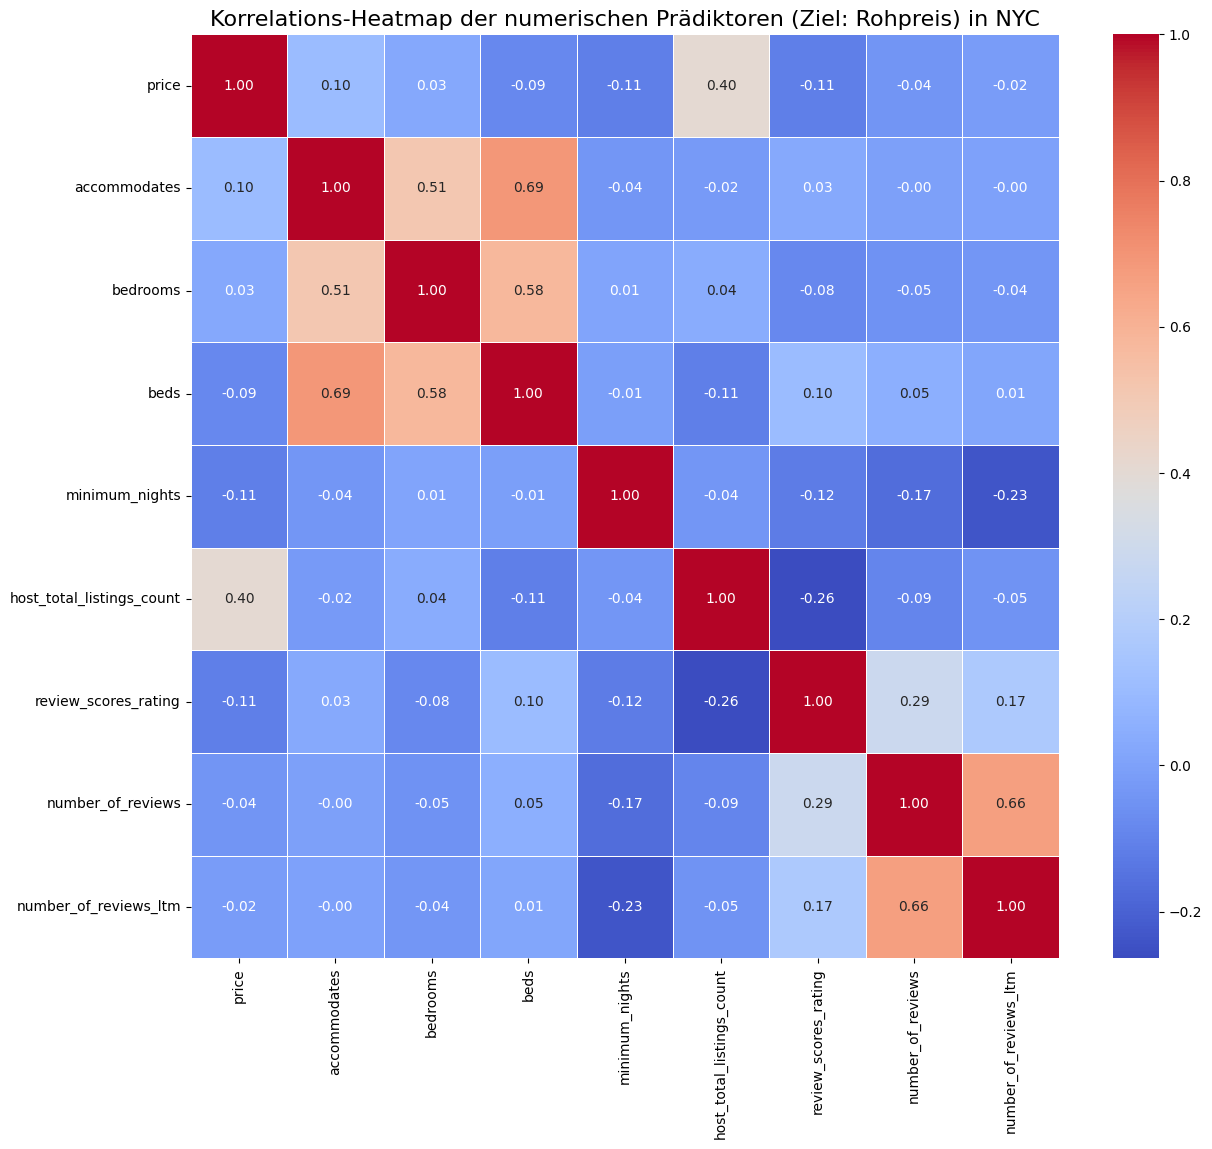

In [78]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --------------------------------------------------------------------------
# A. NUMERISCHE SPALTEN FÜR DIE KORRELATION AUSWÄHLEN
# --------------------------------------------------------------------------
# Wir verwenden price als Zielvariable
numerische_spalten_rohpreis = [
    'price', 'accommodates', 'bedrooms', 'beds',
    'minimum_nights', 'host_total_listings_count', 'review_scores_rating',
    'number_of_reviews', 'number_of_reviews_ltm', 
]

# Wir erstellen den Korrelations-DataFrame. Temporäres Füllen von NaN mit 0
# WICHTIG: Dies ist NUR für die Visualisierung!
corr_matrix_roh = df_nyc[numerische_spalten_rohpreis].fillna(0).corr()


# --------------------------------------------------------------------------
# B. VISUALISIERUNG ALS HEATMAP
# --------------------------------------------------------------------------
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix_roh, 
    annot=True,          # Zeigt die Korrelationswerte in der Zelle an
    fmt=".2f",           # Formatiert auf 2 Dezimalstellen
    cmap='coolwarm',     # Farbschema (rot/blau für positive/negative Korrelation)
    linewidths=.5,       # Linien zwischen den Zellen
    cbar=True            # Farbleiste anzeigen
)
plt.title('Korrelations-Heatmap der numerischen Prädiktoren (Ziel: Rohpreis) in NYC', fontsize=16)
plt.show()

Korrelation zwischen 'price' (abhängige Variable) und host_total_listings_count' am höchsten mit 0.4, eventuell als x-Wert geeignet; 

Wie stelle ich Kausalität sicher?

Antwort gemini: 1. ⚠️ Kausalität vs. Korrelation

Zuerst die wichtigste Klarstellung: Die Korrelationsmatrix kann keine Kausalität (Ursache und Wirkung) beweisen. Sie zeigt lediglich, dass zwei Variablen sich gemeinsam bewegen.

    Korrelation: Wenn X steigt, steigt Y auch (oder fällt).

    Kausalität: Das Steigen von X verursacht das Steigen von Y.

Um die Kausalität zu prüfen (oder zumindest zu argumentieren), müssten Sie ein kontrolliertes Experiment durchführen, was mit historischen Airbnb-Daten unmöglich ist.
Argumentation in der Regression:

In der Regressionsanalyse argumentieren wir für Kausalität, indem wir:

    Logische Plausibilität: Die Kette der Logik ist sinnvoll.

    Statistische Signifikanz: Die Beziehung hält auch dann stand, wenn alle anderen Faktoren berücksichtigt werden (Multivariate Regression).

Multikolinearität zwischen 'accomodates', 'bedrooms', 'beds' bestätigt sich

✅ Log-Preis-Spalte 'ln_price' wurde erstellt.


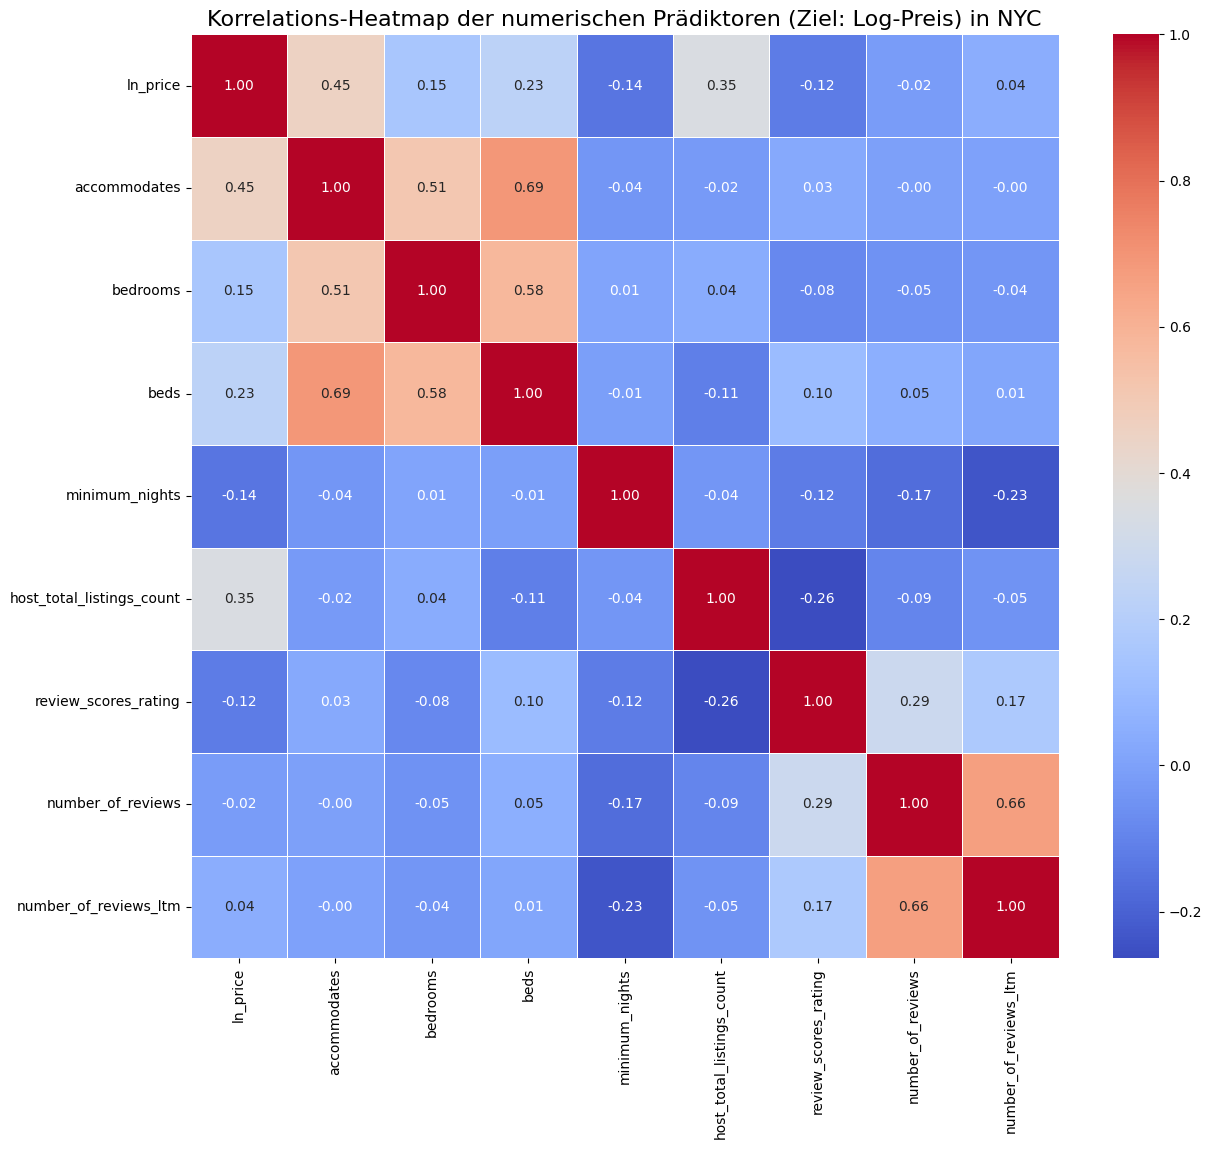

In [79]:
# Führen Sie die Log-Transformation direkt auf df_nyc durch
if 'ln_price' not in df_nyc.columns:
    df_nyc['ln_price'] = np.log(df_nyc['price'])
    print("✅ Log-Preis-Spalte 'ln_price' wurde erstellt.")
else:
    print("Log-Preis-Spalte 'ln_price' ist bereits vorhanden.")


# --------------------------------------------------------------------------
# A. NUMERISCHE SPALTEN FÜR DIE KORRELATION AUSWÄHLEN (ln_price als Ziel)
# --------------------------------------------------------------------------
# Wir verwenden ln_price als Zielvariable und entfernen price, da es jetzt redundant ist.
numerische_spalten_logpreis = [
    'ln_price', 'accommodates', 'bedrooms', 'beds',
    'minimum_nights', 'host_total_listings_count', 'review_scores_rating',
    'number_of_reviews', 'number_of_reviews_ltm', 
]

# Wir erstellen den Korrelations-DataFrame. Temporäres Füllen von NaN mit 0
# WICHTIG: Dies ist NUR für die Visualisierung!
corr_matrix_log = df_nyc[numerische_spalten_logpreis].fillna(0).corr()


# --------------------------------------------------------------------------
# B. VISUALISIERUNG ALS HEATMAP (ln_price)
# --------------------------------------------------------------------------
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix_log, 
    annot=True,          # Zeigt die Korrelationswerte in der Zelle an
    fmt=".2f",           # Formatiert auf 2 Dezimalstellen
    cmap='coolwarm',     # Farbschema (rot/blau für positive/negative Korrelation)
    linewidths=.5,       # Linien zwischen den Zellen
    cbar=True            # Farbleiste anzeigen
)
plt.title('Korrelations-Heatmap der numerischen Prädiktoren (Ziel: Log-Preis) in NYC', fontsize=16)
plt.show()

## Der Mechanismus der Log-Kompression

Die Funktion des natürlichen Logarithmus \( y' = \ln(y) \) ist durch eine abnehmende Steigung gekennzeichnet.

Stellen Sie sich die Skala des Preises vor:

| Preisspanne (Rohdaten) | Transformation (Log-Wert)                 | Differenz (Streckung) | Interpretation                              |
|-------------------------|--------------------------------------------|-------------------------|----------------------------------------------|
| 1 € auf 100 €           | ln(1)=0 → ln(100)≈4.60                    | 4.60 Einheiten          | Der Anfang der Skala wird stark gestreckt.   |
| 500 € auf 600 €         | ln(500)≈6.21 → ln(600)≈6.40               | 0.19 Einheiten          | Das obere Ende der Skala wird stark komprimiert. |


Im Airbnb-Datensatz:

    Dort, wo die meisten Daten sind (kleine Preise): Die meisten Listings kosten zwischen 50 € und 200 €. Ohne ln-Transformation liegen diese Punkte extrem dicht beieinander. Durch die ln-Transformation wird dieser Bereich gestreckt. Die linearen Muster in der am dichtesten besiedelten Datenmasse werden sichtbar, und die Regression kann dort besser lernen.

    Dort, wo die Ausreißer sind (große Preise): Die wenigen extrem teuren Listings (500 €+) würden ohne Transformation die Regressionsgerade stark verzerren. Die ln-Transformation zieht diese Ausreißer näher an den Mittelwert heran und reduziert ihren übermäßigen Einfluss auf das Modell.

Zusammenfassung: Sie zielen darauf ab, die Annahmen der linearen Regression zu erfüllen (insbesondere die Normalität der Residuen und Homoskedastizität). Dies gelingt, indem Sie die Verteilung der Zielvariablen normalisieren. Die ln-Transformation ist die primäre Methode, um dies bei rechtsschiefen Daten (wie dem Preis) zu erreichen, indem sie die kleinen Werte "in den Vordergrund rückt"


Beobachtung: Jetzt ist die positive Korrelation zwischen accommodates und 'ln'price' am höchsten. 

## Vergleich der Kausalitäts-Argumente

| Prädiktor (X)               | Korrelation zu ln(price) | Kausales Argument                                                                                               | Logische Plausibilität                                                                                          |
|-----------------------------|---------------------------|------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------|
| accommodates                | Höchste                   | Die physische Größe des Listings (Ursache) bestimmt die maximalen Kosten und den Marktwert (Wirkung).           | Sehr hoch. Es ist kausal fast zwingend, dass die Größe den Preis bestimmt.                                      |
| host_total_listings_count   | Stark (Rohpreis)          | Ein Host mit vielen Listings (Ursache) agiert professionell und hat höhere Betriebskosten, was höhere Preise ermöglicht (Wirkung). | Mittel. Erfolg könnte zur Expansion führen → mögliche umgekehrte Kausalität oder Scheinkorrelation.             |


# Maximale Reduktion der Gesamttabelle (erstmal Bottom-Up Ansatz)


Basierend auf Ihren Anforderungen und der Korrelationsmatrix definieren wir jetzt das finale Set von Spalten, das in den Modell-DataFrame **df_model** wandert:

| Spalte                          | Typ         | Aktion & Begründung                                                                 |
|---------------------------------|-------------|---------------------------------------------------------------------------------------|
| ln_price                        | Zielvariable| **BEHALTEN.** Muss vorhanden sein.                                                   |
| price                           | Rohdaten    | **LÖSCHEN.** Nach der ln-Transformation redundant.                                   |
| accommodates                    | Numerisch   | **BEHALTEN.** Wichtigster Prädiktor.                                                 |
| beds, bedrooms                  | Numerisch   | **LÖSCHEN.** Multikollinear mit *accommodates*.                                      |
| number_of_reviews_ltm           | Numerisch   | **BEHALTEN.** Wichtige Aktualitätsmetrik.                                            |
| number_of_reviews               | Numerisch   | **LÖSCHEN.** Redundant zu *number_of_reviews_ltm*.                                   |
| review_scores_rating            | Numerisch   | **BEHALTEN.** Wichtige Qualitätsmetrik (muss imputiert werden).                      |
| host_total_listings_count       | Numerisch   | **BEHALTEN.** Indikator für Professionalität.                                        |
| minimum_nights                  | Numerisch   | **BEHALTEN.** Wichtiger Preisfaktor (negative Korrelation).                          |
| latitude, longitude             | Geodaten    | **BEHALTEN.** Benötigt für Feature Engineering.                                      |
| room_type                       | Kategorial  | **BEHALTEN.** Wird für One-Hot-Encoding benötigt.                                     |
| neighbourhood_group_cleansed    | Kategorial  | **BEHALTEN.** Wird für One-Hot-Encoding benötigt.                                     |
| Restliche IDs/Metadaten         | Alle anderen| **LÖSCHEN.** (z.B. id, host_id, host_listings_count etc.)                             |


Weitere Projektplanung: 

## ⏳ Zeitschätzung: Datenbank- und Funktionsvorbereitung

| Phase                           | Schritte                                                                                                                                             | Erwarteter Aufwand | Fokus                                         |
|---------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------|---------------------|-----------------------------------------------|
| I. Datenbank-Infrastruktur      | PostgreSQL-Datenbank & Schema einrichten, Tabelle erstellen, Zugangsdaten in Python speichern (z.B. `.env` oder Konfigurationsdatei).               | 2–4 Stunden         | Infrastruktur einmalig aufsetzen.             |
| II. ETL-Funktion (Phase 1)      | Funktion `bereinige_fuer_datenbank(df_city)`: Preis-Parsing, Löschen irrelevanter Spalten, Entfernen von Zeilen ohne Preis.                         | 4–6 Stunden         | Hauptteil der Arbeit, muss robust sein.        |
| III. ETL-Funktion (Phase 2)     | Funktion `bereite_fuer_regression_vor(df_city, center_coords)`: Log-Transformation, Feature Engineering, OHE, Imputation vorbereiten.               | 6–8 Stunden         | Höhere Komplexität (v.a. OHE + Haversine).     |
| IV. Datenbank-Integration       | Ladefunktion schreiben: Verbindung zur DB, Einfügen der Daten (psycopg2/SQLAlchemy), Test mit kleinem Datensatz.                                      | 4–6 Stunden         | Fehlerbehandlung der DB-Schnittstelle.         |
| V. Gesamttest & Iteration       | Auf zweite Stadt anwenden, Spalten prüfen, Debugging bei Randfällen (z.B. neue Kategorien in `room_type`).                                           | 4–8 Stunden         | Unvermeidbares Debugging.                      |
| **GESAMT**                      |                                                                                                                                                      | **ca. 20–32 Stunden** |                                               |




## Gesamtarchitektur Ihres Projekts (GitHub-Repo)

Ihre Projektstruktur sollte die Trennung von Code (Funktionen), Daten (Roh- & Ergebnisdaten) und Dokumentation (Notebooks) widerspiegeln.

### 1. 📁 Die Ordnerstruktur

| Ordner / Datei        | Zweck                       | Inhalt (Beispiele)                                                   |
|-----------------------|-----------------------------|-----------------------------------------------------------------------|
| `src/`                | Source Code / Funktionen    | Alle Python-Definitionen, die wiederverwendbar sind.                 |
| `data/`               | Daten                       | Rohdaten (sollten nicht im Repo liegen, da zu groß).                 |
| `data/processed/`     | Verarbeitete Daten          | Kleine, finale Datensätze, falls sie ohne DB gespeichert werden.     |
| `notebooks/`          | Analyse & Dokumentation     | Story, Visualisierungen, Erklärungen.                                |
| `README.md`           | Einstiegspunkt              | Projektbeschreibung, Installation, Start der Skripte.                |
| `requirements.txt`    | Abhängigkeiten              | Liste der Python-Bibliotheken (z.B. pandas, numpy, psycopg2).        |


Integration der Python-Definitionen

Ihre Funktionen für das Einpflegen der Städte (bereinige_fuer_datenbank und bereite_fuer_regression_vor) gehören in den Ordner src/, nicht in Ihr Haupt-Notebook.
A. src/data_cleaning.py

Dieser Skript enthält alle Definitionen der universellen Bereinigungsfunktionen (Phase 1 & 2):

    def bereinige_fuer_datenbank(df_city)

    def transformiere_fuer_sql(df_city)

    def calculate_distance(...) (Ihre Haversine-Funktion)

B. src/etl_pipeline.py (optional, aber gut)

Ein Skript, das die Funktionen aus data_cleaning.py aufruft, um alle 10 Städte zu laden und in die Datenbank zu schreiben.


## Rolle des Notebooks: Dokumentation vs. Entwicklung

Ihre aktuelle Nutzung des Notebooks ist völlig richtig und spiegelt genau den Entwicklungs- und Analyseprozess eines Data Scientists wider.

| Ihre Nutzung (Entwicklung)      | VS | Ziel im Industrieprojekt (Dokumentation)                                                                 |
|----------------------------------|----|------------------------------------------------------------------------------------------------------------|
| **Schrittweise Ideenentwicklung** | Entdeckung | Das Notebook ist „Notizblock“ und „Laborbericht“ für EDA, Hypothesen und Visualisierungen.                |
| **Entscheidungsfindung**         | Dokumentation | Alle Entscheidungen (z.B. `ln(price)` statt `price`, Löschen von `beds`) müssen im Notebook begründet werden — Ihr Audit-Trail. |
| **Code-Entwurf**                 | Prototyping | Code entsteht im Notebook und wird später in saubere `.py`-Funktionen in `src/` überführt.                |
| **Finale Version**               | Storytelling | Das finale Notebook zeigt die komplette Projektstory: Motivation → Bereinigung → EDA → Modell → Ergebnisse → Fazit. |


# Haversine-Berechnung 

Eine weitere Variable der linearen Regression soll der Abstand zum festgelegten Stadtzentrum sein (in NYC die Distanz zum Times Square)

siehe Python-Modul 

# Überlegungen zum Einsatz von KI-Agenten und KI-Pipelines

Der Einsatz von KI-Agenten und automatisierten Pipelines (CI/CD und MLOps) ist die Zukunft der Datenwissenschaft. Ihr Dozent hat hier einen wichtigen Punkt angesprochen.

Eine Pipeline im Kontext von Machine Learning (MLOps) beschreibt eine automatisierte Kette von Schritten, die Daten in ein Modell umwandeln und dieses bereitstellen.
Die Vision: Automatisierte MLOps-Pipeline

Ihre jetzigen Schritte können Sie in eine Pipeline überführen, die theoretisch von einem KI-Agenten überwacht oder gesteuert werden könnte:


| Aktueller Schritt                  | Pipeline-Phase      | Rolle eines KI-Agenten (Vision)                                                                                 |
|-----------------------------------|----------------------|------------------------------------------------------------------------------------------------------------------|
| Daten sammeln                     | Extract              | Überwachung: Stellt sicher, dass die Rohdaten-Quelle (z.B. Airbnb-Scrape-Link) erreichbar ist.                  |
| Daten bereinigen (Phase 1)        | Transform (ETL)      | Automatische Typkonvertierung: Erkennt Datentypen und wendet `transformiere_fuer_sql` an, um Daten DB-fertig zu machen. |
| DB füllen                         | Load                 | Job-Orchestrierung: Überprüft, ob alle 10 Städte erfolgreich in die PostgreSQL-DB geladen wurden.               |
| Modelltraining                    | Model Training       | Hyperparameter-Optimierung: Testet verschiedene Regressionen und wählt die beste Feature-Kombination.           |
| Modellbewertung                   | Model Validation     | Drift-Erkennung: Erkennt Änderungen in der NYC-Preisverteilung und empfiehlt Retraining.                        |

